<a href="https://colab.research.google.com/github/srinidhibv1403/Truth-Trace-LLM/blob/main/dataexplorationandvisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [11]:
pd.set_option('display.max_colwidth', None)
sns.set(style="whitegrid")

In [14]:
true_path = "/content/True.csv"
fake_path = "/content/Fake.csv"

In [16]:
true_df = pd.read_csv(true_path, on_bad_lines='skip', engine='python')
fake_df = pd.read_csv(fake_path, on_bad_lines='skip', engine='python')

In [17]:
true_df['label'] = 'True'
fake_df['label'] = 'Fake'

In [18]:
print("Shape of True dataset:", true_df.shape)

Shape of True dataset: (7583, 5)


In [19]:
print("Shape of Fake dataset:", fake_df.shape)

Shape of Fake dataset: (6953, 5)


In [20]:
data = pd.concat([true_df, fake_df]).reset_index(drop=True)
print("\nCombined dataset info:")
print(data.info())


Combined dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14536 entries, 0 to 14535
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    14536 non-null  object
 1   text     14536 non-null  object
 2   subject  14536 non-null  object
 3   date     14536 non-null  object
 4   label    14536 non-null  object
dtypes: object(5)
memory usage: 567.9+ KB
None


In [21]:
print("\nMissing values:\n", data.isnull().sum())


Missing values:
 title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [22]:
print("\nSample data:\n", data.head())


Sample data:
                                                                    title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [23]:
print("\nDataset Description:")
print(data.describe(include='all'))


Dataset Description:
                                                       title  \
count                                                  14536   
unique                                                 14443   
top     Factbox: Trump fills top jobs for his administration   
freq                                                      14   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [24]:
data['word_count'] = data['text'].apply(lambda x: len(str(x).split()))
data['char_count'] = data['text'].apply(lambda x: len(str(x)))
data['title_len'] = data['title'].apply(lambda x: len(str(x)))

/tmp/ipython-input-3504368588.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, palette='coolwarm')


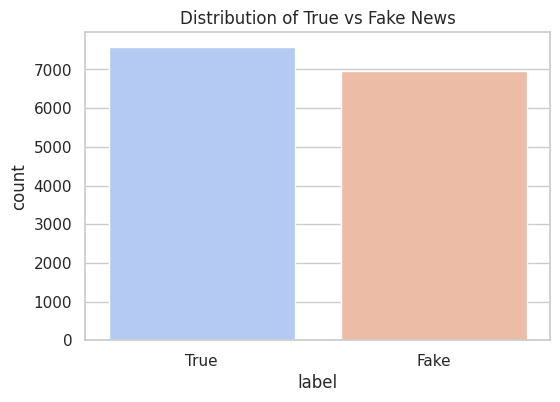

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=data, palette='coolwarm')
plt.title('Distribution of True vs Fake News')
plt.show()

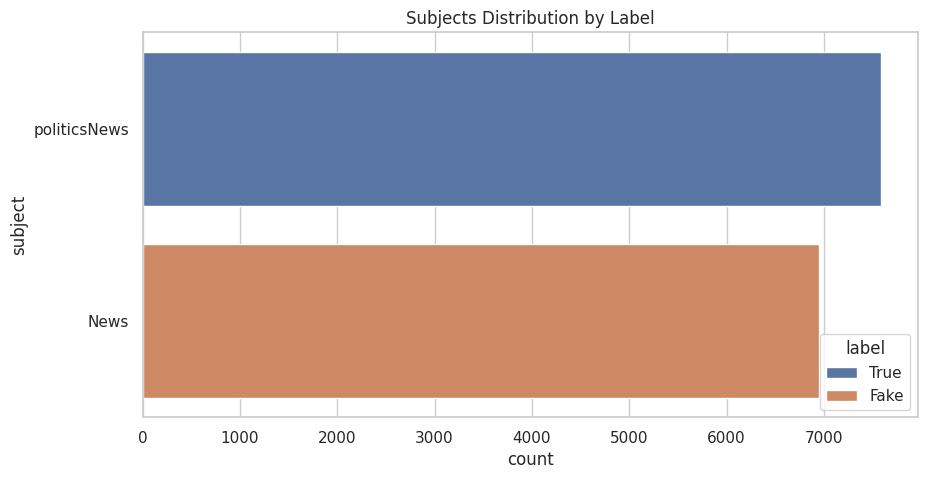

In [26]:
if 'subject' in data.columns:
    plt.figure(figsize=(10,5))
    sns.countplot(y='subject', hue='label', data=data)
    plt.title('Subjects Distribution by Label')
    plt.show()

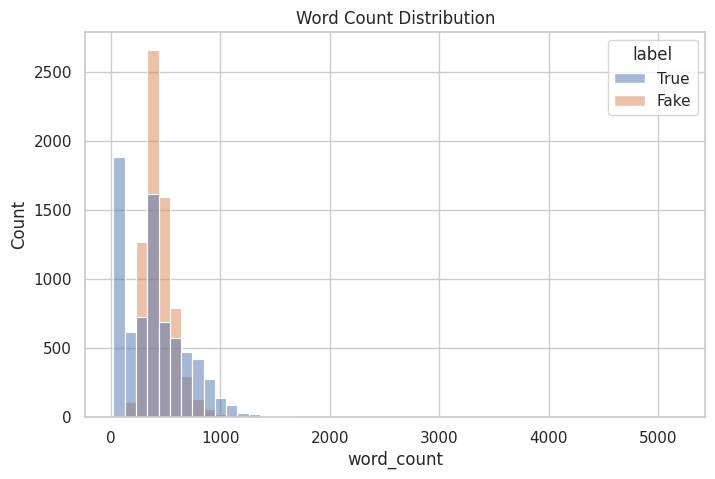

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(data, x='word_count', hue='label', bins=50)
plt.title('Word Count Distribution')
plt.show()

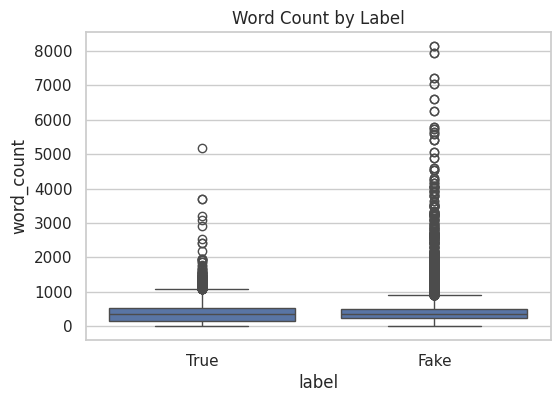

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x='label', y='word_count', data=data)
plt.title('Word Count by Label')
plt.show()

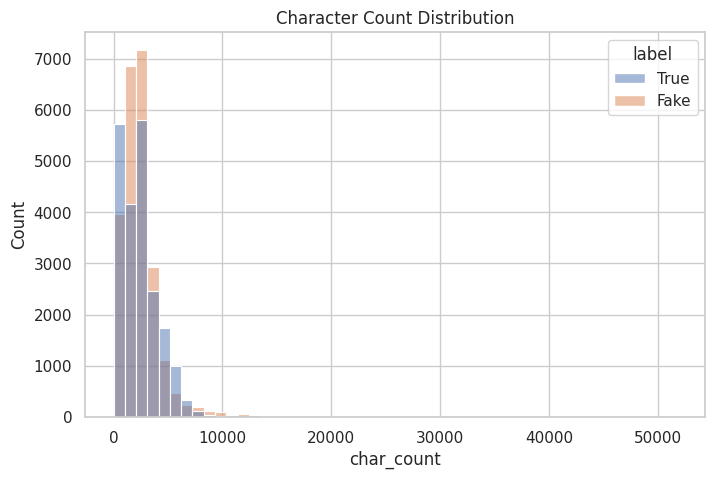

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(data, x='char_count', hue='label', bins=50)
plt.title('Character Count Distribution')
plt.show()

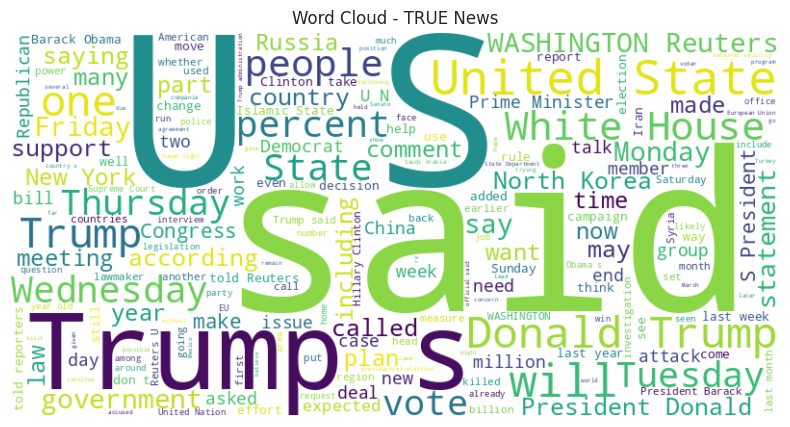

In [30]:
true_words = ' '.join(true_df['text'])
wc_true = WordCloud(width=800, height=400, background_color='white').generate(true_words)
plt.figure(figsize=(10,5))
plt.imshow(wc_true, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - TRUE News')
plt.show()

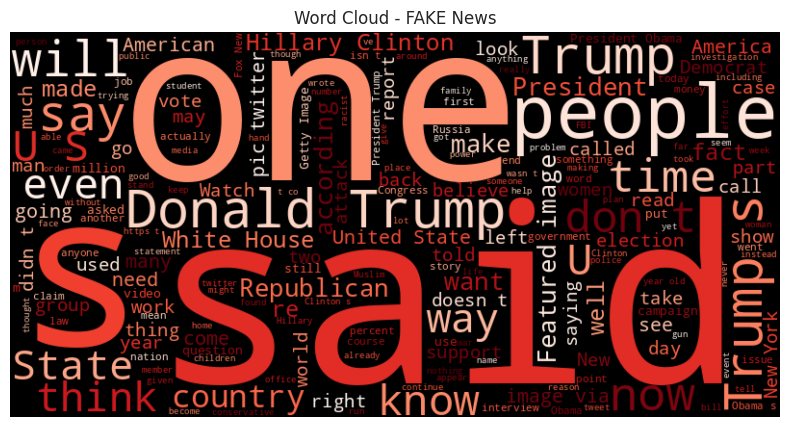

In [31]:
fake_words = ' '.join(fake_df['text'])
wc_fake = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(fake_words)
plt.figure(figsize=(10,5))
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - FAKE News')
plt.show()

/tmp/ipython-input-4005195110.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wc_df, y='word', x='count', palette='mako')


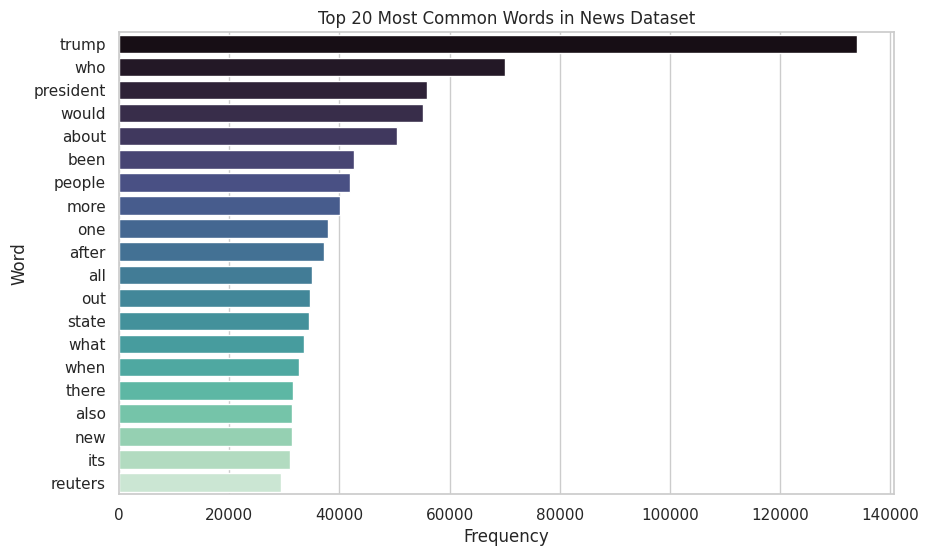

In [41]:

from collections import Counter
import re

all_text = ' '.join(data['text'].astype(str)).lower()

words = re.findall(r'\b[a-z]{3,}\b', all_text)

stopwords = set([
    'the','and','for','that','with','this','from','was','are','have','you','not',
    'his','her','she','him','has','had','were','they','their','which','will','but','said'
])
filtered_words = [w for w in words if w not in stopwords]

word_counts = Counter(filtered_words).most_common(20)

wc_df = pd.DataFrame(word_counts, columns=['word', 'count'])

plt.figure(figsize=(10,6))
sns.barplot(data=wc_df, y='word', x='count', palette='mako')
plt.title('Top 20 Most Common Words in News Dataset')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()


/tmp/ipython-input-4001836879.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y='word_count', data=data, palette='Set2')


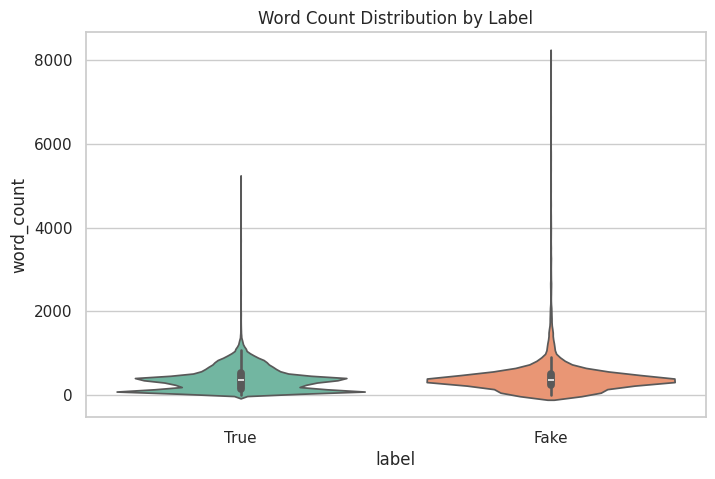

In [42]:
plt.figure(figsize=(8,5))
sns.violinplot(x='label', y='word_count', data=data, palette='Set2')
plt.title('Word Count Distribution by Label')
plt.show()

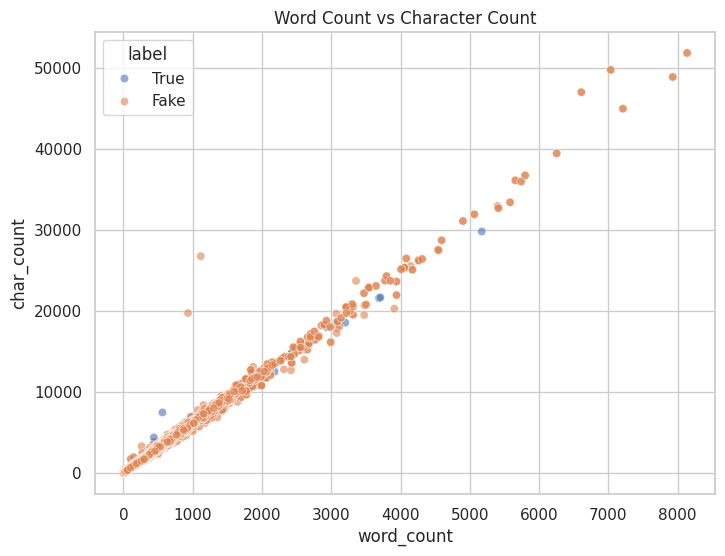

In [43]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='word_count', y='char_count', hue='label', data=data, alpha=0.6)
plt.title('Word Count vs Character Count')
plt.show()

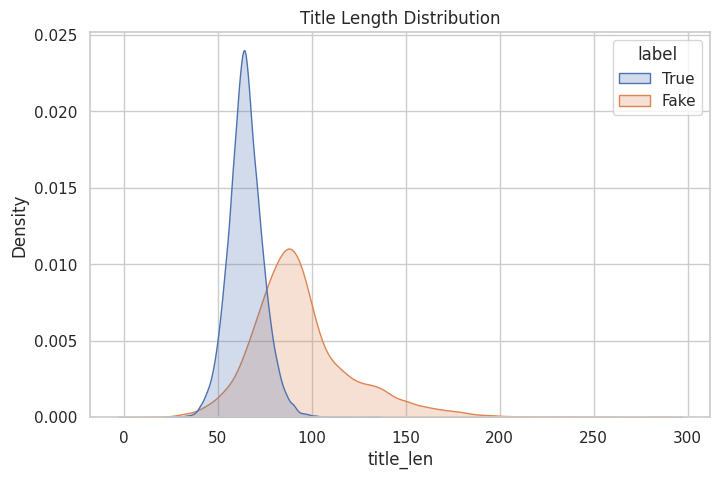

In [44]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=data, x='title_len', hue='label', fill=True)
plt.title('Title Length Distribution')
plt.show()

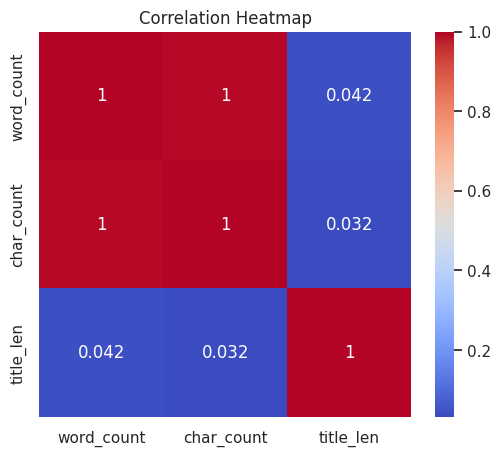

In [45]:
plt.figure(figsize=(6,5))
sns.heatmap(data[['word_count', 'char_count', 'title_len']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


/tmp/ipython-input-222673543.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='title_len', data=data, palette='pastel')


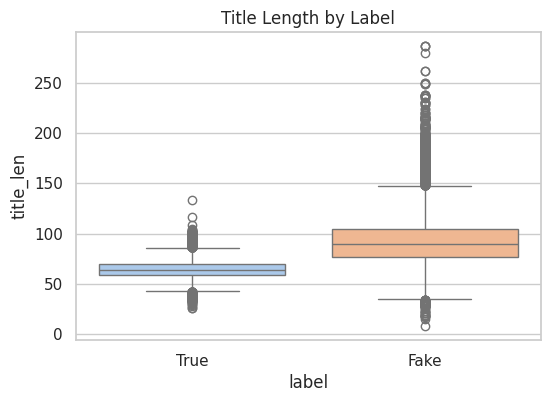

In [46]:
plt.figure(figsize=(6,4))
sns.boxplot(x='label', y='title_len', data=data, palette='pastel')
plt.title('Title Length by Label')
plt.show()

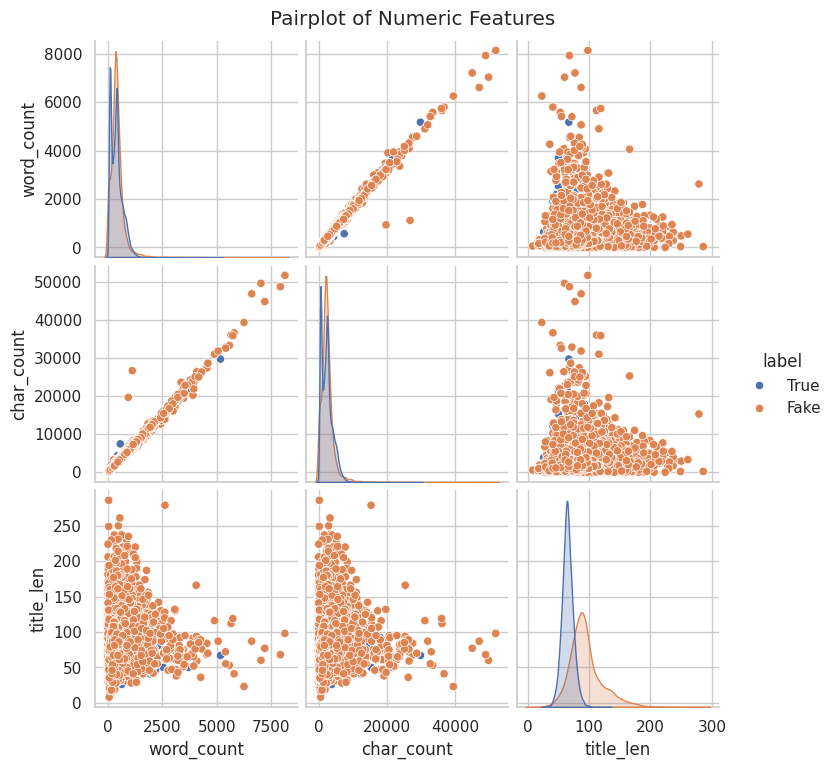

In [47]:
sns.pairplot(data[['word_count','char_count','title_len','label']], hue='label')
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()

/tmp/ipython-input-3894960730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='label', y='word_count', data=data, jitter=True, alpha=0.5, palette='Set2')


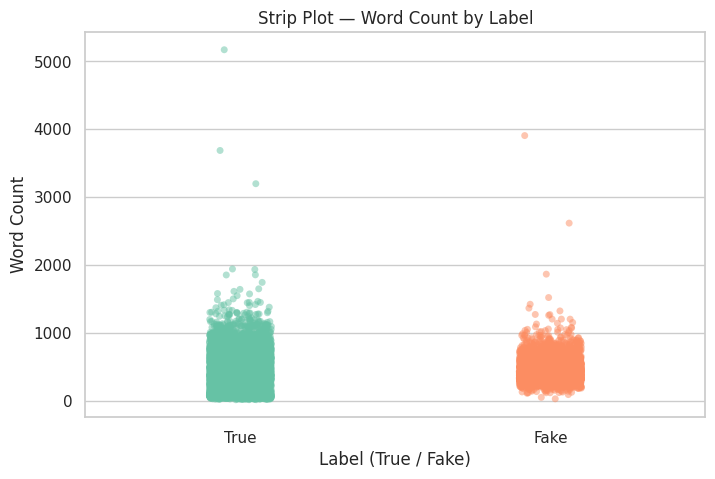

In [29]:

plt.figure(figsize=(8, 5))
sns.stripplot(x='label', y='word_count', data=data, jitter=True, alpha=0.5, palette='Set2')
plt.title('Strip Plot — Word Count by Label')
plt.xlabel('Label (True / Fake)')
plt.ylabel('Word Count')
plt.show()



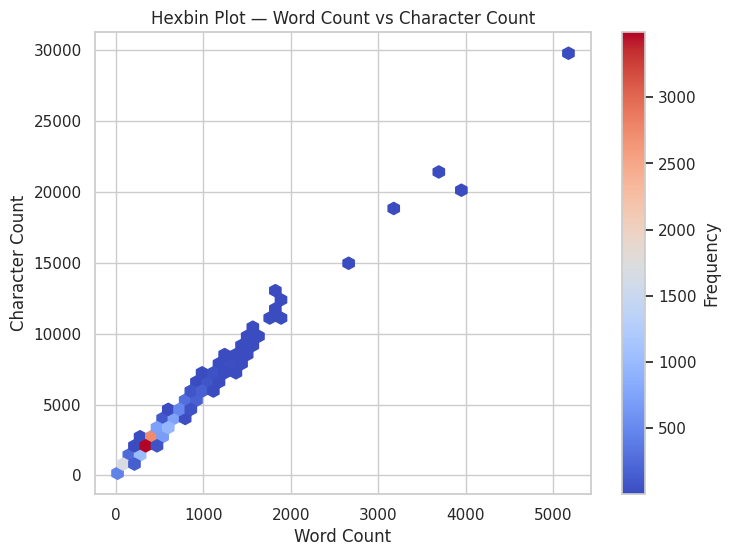

In [30]:

plt.figure(figsize=(8, 6))
plt.hexbin(data['word_count'], data['char_count'], gridsize=40, cmap='coolwarm', mincnt=1)
plt.colorbar(label='Frequency')
plt.title('Hexbin Plot — Word Count vs Character Count')
plt.xlabel('Word Count')
plt.ylabel('Character Count')
plt.show()
